# Lab 2: Multi-Class Human Activity Recognition & Model Quantization Scheme Analysis

## Aim

To collect multi-axis smartphone accelerometer data for three human activity classes
(**Idle**, **Walking**, **Sit-ups**) using the phyphox application, to train a lightweight
3-class Human Activity Recognition (HAR) classifier, and to convert the trained model into
four TensorFlow Lite (TFLite) variants:

- **A.** Float32 Baseline (Unquantized)
- **B.** Dynamic Range Quantization
- **C.** Float16 Quantization
- **D.** Full Integer Post-Training Quantization (PTQ)

The four variants are then benchmarked on model file size, classification accuracy,
memory reduction, and average inference time per window, to study the trade-offs involved
in deploying a HAR model on a resource-constrained (TinyML) microcontroller-class device.

## Objectives

1. Record real accelerometer data for Idle, Walking and Sit-ups using phyphox.
2. Clean and preprocess the raw accelerometer signals.
3. Segment the continuous signals into 1-second (100-sample) windows.
4. Compute the 3D acceleration magnitude for every sample in every window.
5. Extract Mean, Standard Deviation and RMS features from the acceleration magnitude of each window.
6. Build the feature matrix `X` and label vector `y`, and perform a stratified train/test split.
7. Train a small 3-class Multi-Layer Perceptron (MLP) on the extracted features.
8. Evaluate the Float32 baseline model on the held-out test set.
9. Convert the trained model into four TFLite variants (Float32, Dynamic Range, Float16, Full Integer PTQ).
10. Run inference with all four TFLite models on the same test set.
11. Automatically compute model size, accuracy, memory reduction and inference latency for each variant.
12. Compare and discuss the four quantization schemes, with emphasis on why Full Integer PTQ
    matters for ultra-low-power wearable, on-device activity recognition.

**Note:** The physical datasets have not been collected yet. This notebook is designed to be
run **after** placing `idle.csv`, `walking.csv` and `situps.csv` inside the `dataset/` folder.
No synthetic data, fabricated results, or hard-coded metrics are used anywhere in this notebook.

## 0. Imports & Global Configuration

All required libraries are imported here, and a global random seed is fixed for reproducibility.

In [1]:
import os
import io
import time
import glob
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

CLASS_NAMES = ["Idle", "Walking", "Sit-ups"]
LABEL_MAP = {"Idle": 0, "Walking": 1, "Sit-ups": 2}

print("TensorFlow version:", tf.__version__)
print("Random seed set to:", RANDOM_STATE)

TensorFlow version: 2.20.0
Random seed set to: 42


## 1. Smartphone + phyphox

The smartphone's built-in accelerometer is used as the sensing device, and the **phyphox**
application (Physical Phone Experiments, RWTH Aachen University) is used to record the
raw acceleration data.

**Data collection procedure:**

- The smartphone is securely fixed against the **chest or waist** (a consistent mounting
  location and orientation should be used across all recordings).
- The **phyphox** app is opened on the smartphone.
- The **Accelerometer** (or **Linear Acceleration**) experiment is selected.
- The phone's orientation is kept **consistent** throughout data collection, since a change
  in orientation would change the axis definitions of the recorded signal.
- Data is recorded separately for each of the three activity classes:
  - **Idle** (sitting/standing still)
  - **Walking**
  - **Sit-ups**
- Each recording is exported from phyphox as a CSV file.

No Python code is required for this physical setup step; this cell is included purely for
documentation of the experimental procedure as part of the lab record.

## 2. Accelerometer Data Acquisition

The phyphox accelerometer experiment records three axes of acceleration:

- **ax** — acceleration along the X-axis
- **ay** — acceleration along the Y-axis
- **az** — acceleration along the Z-axis

Data is acquired for the three required activities:

- **Idle / Sitting**
- **Walking**
- **Sit-ups**

The target sampling rate specified for this experiment is approximately **100 samples/second**.
The raw, continuous accelerometer stream recorded for each activity will later (Section 5) be
segmented into non-overlapping **1-second windows** (i.e. 100 samples per window).

No fake or synthetic data is created at this stage. The cell below only defines the expected
file paths/configuration for the dataset; it does **not** attempt to load any files yet.

In [2]:
import os
os.makedirs("dataset", exist_ok=True)

In [3]:
# --- Dataset configuration ---
DATA_DIR = "dataset"

IDLE_FILE = os.path.join(DATA_DIR, "idle.csv")
WALKING_FILE = os.path.join(DATA_DIR, "walking.csv")
SITUPS_FILE = os.path.join(DATA_DIR, "situps.csv")

TARGET_SAMPLING_RATE_HZ = 100
WINDOW_DURATION_SEC = 1
WINDOW_SIZE = TARGET_SAMPLING_RATE_HZ * WINDOW_DURATION_SEC

print("Expected dataset directory:", DATA_DIR)
print("Expected files:")
print(" -", IDLE_FILE)
print(" -", WALKING_FILE)
print(" -", SITUPS_FILE)
print("Target sampling rate (Hz):", TARGET_SAMPLING_RATE_HZ)
print("Window size (samples):", WINDOW_SIZE)

Expected dataset directory: dataset
Expected files:
 - dataset/idle.csv
 - dataset/walking.csv
 - dataset/situps.csv
Target sampling rate (Hz): 100
Window size (samples): 100


## 3. Raw Activity Datasets

The three raw CSV files collected from phyphox are expected to be:

- `idle.csv`
- `walking.csv`
- `situps.csv`

Each file should contain acceleration measurements for the three axes: `ax`, `ay`, `az`
(phyphox typically exports columns such as `Time (s)`, `Acceleration x (m/s^2)`,
`Acceleration y (m/s^2)`, `Acceleration z (m/s^2)`, or similarly named variants).

The loader below is made robust to common phyphox column-naming variations. For each file it:

- Checks whether the CSV exists.
- Loads the CSV dynamically if present.
- Displays the shape of the loaded data.
- Displays the first few rows.
- Displays the detected column names.
- Attempts to automatically identify the timestamp and X/Y/Z acceleration columns.

If a required file is missing, a clear message is printed instead of generating replacement data.
The actual number of rows is **not** hard-coded anywhere, since the real data has not yet been collected.

In [4]:
def identify_columns(df):
    """
    Attempt to automatically identify the timestamp and ax/ay/az columns
    from a phyphox-exported dataframe, tolerating common naming variations.
    Returns a dict: {'time': col_or_None, 'ax': col_or_None, 'ay': col_or_None, 'az': col_or_None}
    """
    cols_lower = {c: c.lower().strip() for c in df.columns}
    detected = {"time": None, "ax": None, "ay": None, "az": None}

    for original, lower in cols_lower.items():
        if detected["time"] is None and ("time" in lower):
            detected["time"] = original
        if detected["ax"] is None and (
            lower in ("ax", "x", "acceleration x", "acceleration x (m/s^2)", "acceleration x (m/s2)")
            or ("acceleration" in lower and lower.endswith("x") is False and " x" in lower)
        ):
            detected["ax"] = original
        if detected["ay"] is None and (
            lower in ("ay", "y", "acceleration y", "acceleration y (m/s^2)", "acceleration y (m/s2)")
            or ("acceleration" in lower and " y" in lower)
        ):
            detected["ay"] = original
        if detected["az"] is None and (
            lower in ("az", "z", "acceleration z", "acceleration z (m/s^2)", "acceleration z (m/s2)")
            or ("acceleration" in lower and " z" in lower)
        ):
            detected["az"] = original

    # Fallback: if still missing, try simple substring matches on 'x'/'y'/'z' at token boundaries
    for axis, key in zip(["x", "y", "z"], ["ax", "ay", "az"]):
        if detected[key] is None:
            for original, lower in cols_lower.items():
                tokens = lower.replace("(", " ").replace(")", " ").replace(",", " ").split()
                if axis in tokens:
                    detected[key] = original
                    break

    return detected


def load_activity_csv(filepath, activity_name):
    """
    Dynamically load a single activity CSV file, or report clearly if it is missing.
    Returns (dataframe_or_None, column_map_or_None).
    """
    if not os.path.exists(filepath):
        print(f"[{activity_name}] Dataset not found at '{filepath}'.")
        print(f"[{activity_name}] Place idle.csv, walking.csv and situps.csv inside the "
              f"'{DATA_DIR}' folder and rerun this cell.")
        return None, None

    df = pd.read_csv(filepath)
    col_map = identify_columns(df)

    print(f"--- {activity_name} ---")
    print("File:", filepath)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("Detected column mapping:", col_map)
    display(df.head())
    print()

    return df, col_map


# Attempt to load all three raw datasets (will only succeed once real CSVs are placed)
raw_idle_df, idle_cols = load_activity_csv(IDLE_FILE, "Idle")
raw_walking_df, walking_cols = load_activity_csv(WALKING_FILE, "Walking")
raw_situps_df, situps_cols = load_activity_csv(SITUPS_FILE, "Sit-ups")

RAW_DATA = {
    "Idle": (raw_idle_df, idle_cols),
    "Walking": (raw_walking_df, walking_cols),
    "Sit-ups": (raw_situps_df, situps_cols),
}

datasets_ready = all(df is not None for df, _ in RAW_DATA.values())
print("All three datasets available:", datasets_ready)

--- Idle ---
File: dataset/idle.csv
Shape: (22795, 5)
Columns: ['Time (s)', 'Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)', 'Absolute acceleration (m/s^2)']
Detected column mapping: {'time': 'Time (s)', 'ax': 'Linear Acceleration x (m/s^2)', 'ay': 'Linear Acceleration y (m/s^2)', 'az': 'Linear Acceleration z (m/s^2)'}


,Time (s),Linear Acceleration x (m/s^2),Linear Acceleration y (m/s^2),Linear Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.020280,-0.012026,0.287814,0.210193,0.356598
1,0.028280,-0.037514,0.189491,-0.348894,0.398799
2,0.036283,-0.025940,0.257637,-0.561506,0.618335
3,0.044283,-0.062300,0.394593,-0.549141,0.679074
4,0.052284,-0.092543,0.473767,-0.445518,0.656891



--- Walking ---
File: dataset/walking.csv
Shape: (23998, 5)
Columns: ['Time (s)', 'Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)', 'Absolute acceleration (m/s^2)']
Detected column mapping: {'time': 'Time (s)', 'ax': 'Linear Acceleration x (m/s^2)', 'ay': 'Linear Acceleration y (m/s^2)', 'az': 'Linear Acceleration z (m/s^2)'}


,Time (s),Linear Acceleration x (m/s^2),Linear Acceleration y (m/s^2),Linear Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.021012,-0.025778,-0.201612,-0.117768,0.234906
1,0.029007,0.247892,-0.025756,-0.488980,0.548830
2,0.037001,0.544191,0.101277,-0.579232,0.801194
3,0.044996,0.462890,0.176133,-0.266494,0.562414
4,0.052995,0.245034,0.191184,0.021110,0.311510



--- Sit-ups ---
File: dataset/situps.csv
Shape: (24178, 5)
Columns: ['Time (s)', 'Linear Acceleration x (m/s^2)', 'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)', 'Absolute acceleration (m/s^2)']
Detected column mapping: {'time': 'Time (s)', 'ax': 'Linear Acceleration x (m/s^2)', 'ay': 'Linear Acceleration y (m/s^2)', 'az': 'Linear Acceleration z (m/s^2)'}


,Time (s),Linear Acceleration x (m/s^2),Linear Acceleration y (m/s^2),Linear Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.028004,-0.001797,-0.090716,-0.028825,0.095203
1,0.036006,-0.026516,-0.028671,-0.118579,0.124845
2,0.044011,0.088801,0.024722,-0.370167,0.381472
3,0.052014,0.166099,0.010492,-0.458999,0.488241
4,0.060017,0.058456,-0.051983,-0.370905,0.379064



All three datasets available: True


## 4. Data Cleaning & Preprocessing

Before windowing, each raw activity recording is cleaned:

- Missing values are removed.
- Non-numeric acceleration values are removed.
- Acceleration columns (`ax`, `ay`, `az`) are converted to numeric type.
- Duplicate timestamps are handled (dropped) if a timestamp column exists.
- Rows are sorted by timestamp when a timestamp column exists.
- The sampling interval is inspected and the sampling frequency is estimated from the data,
  so that it can be compared against the target of ~100 Hz.

Before/after dataset shapes are displayed so that no large, unexplained loss of data goes unnoticed.
A visualization of the raw acceleration signals (X, Y, Z) is also produced for each activity.

In [5]:
def clean_activity_df(df, col_map, activity_name):
    """
    Clean a single activity dataframe:
      - keep only relevant columns (time, ax, ay, az) where available
      - coerce acceleration columns to numeric
      - drop missing / invalid rows
      - drop duplicate timestamps and sort by time (if a timestamp column exists)
      - estimate the sampling frequency
    Returns (cleaned_df, estimated_fs_hz_or_None)
    """
    if df is None:
        return None, None

    before_shape = df.shape

    time_col, ax_col, ay_col, az_col = col_map["time"], col_map["ax"], col_map["ay"], col_map["az"]

    keep_cols = [c for c in [time_col, ax_col, ay_col, az_col] if c is not None]
    work_df = df[keep_cols].copy()

    rename_map = {}
    if time_col is not None:
        rename_map[time_col] = "time"
    if ax_col is not None:
        rename_map[ax_col] = "ax"
    if ay_col is not None:
        rename_map[ay_col] = "ay"
    if az_col is not None:
        rename_map[az_col] = "az"
    work_df = work_df.rename(columns=rename_map)

    # Convert acceleration columns to numeric, coercing invalid entries to NaN
    for c in ["ax", "ay", "az"]:
        if c in work_df.columns:
            work_df[c] = pd.to_numeric(work_df[c], errors="coerce")
    if "time" in work_df.columns:
        work_df["time"] = pd.to_numeric(work_df["time"], errors="coerce")

    # Drop rows with any missing / invalid values in required columns
    required_cols = [c for c in ["ax", "ay", "az"] if c in work_df.columns]
    work_df = work_df.dropna(subset=required_cols)

    # Handle duplicate timestamps and sort chronologically
    est_fs = None
    if "time" in work_df.columns:
        work_df = work_df.drop_duplicates(subset=["time"])
        work_df = work_df.sort_values("time").reset_index(drop=True)

        if len(work_df) > 1:
            intervals = np.diff(work_df["time"].values)
            intervals = intervals[intervals > 0]
            if len(intervals) > 0:
                median_interval = np.median(intervals)
                est_fs = 1.0 / median_interval if median_interval > 0 else None
    else:
        work_df = work_df.reset_index(drop=True)

    after_shape = work_df.shape

    print(f"--- {activity_name}: cleaning summary ---")
    print("Shape before cleaning:", before_shape)
    print("Shape after cleaning :", after_shape)
    if est_fs is not None:
        print(f"Estimated sampling rate: {est_fs:.2f} Hz")
    else:
        print("Estimated sampling rate: could not be determined (no usable timestamp column)")
    print()

    return work_df, est_fs


CLEAN_DATA = {}
for activity_name, (raw_df, col_map) in RAW_DATA.items():
    cleaned_df, est_fs = clean_activity_df(raw_df, col_map, activity_name)
    CLEAN_DATA[activity_name] = {"df": cleaned_df, "fs": est_fs}

--- Idle: cleaning summary ---
Shape before cleaning: (22795, 5)
Shape after cleaning : (22795, 4)
Estimated sampling rate: 124.96 Hz

--- Walking: cleaning summary ---
Shape before cleaning: (23998, 5)
Shape after cleaning : (23998, 4)
Estimated sampling rate: 124.97 Hz

--- Sit-ups: cleaning summary ---
Shape before cleaning: (24178, 5)
Shape after cleaning : (24178, 4)
Estimated sampling rate: 125.00 Hz



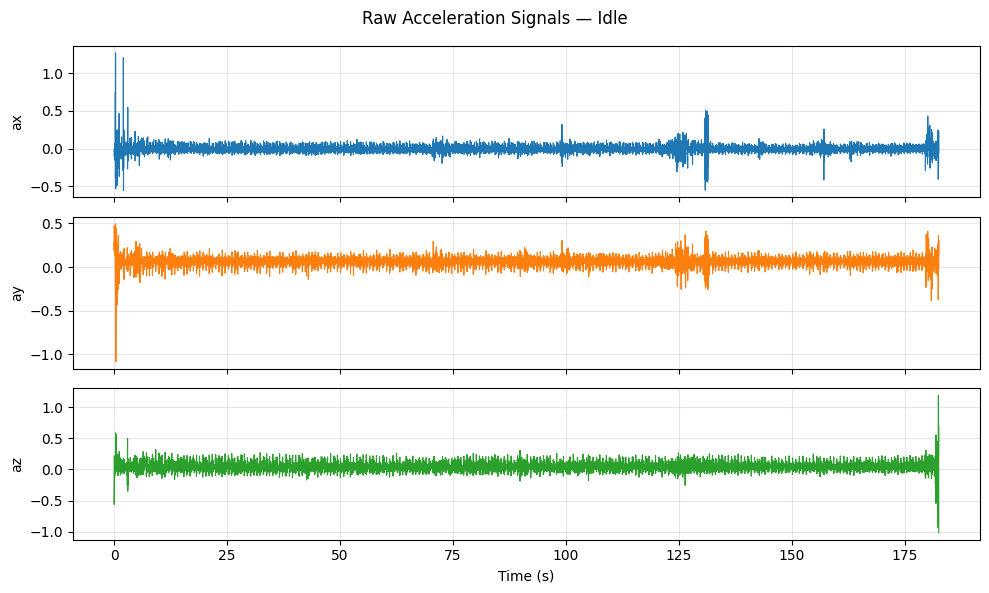

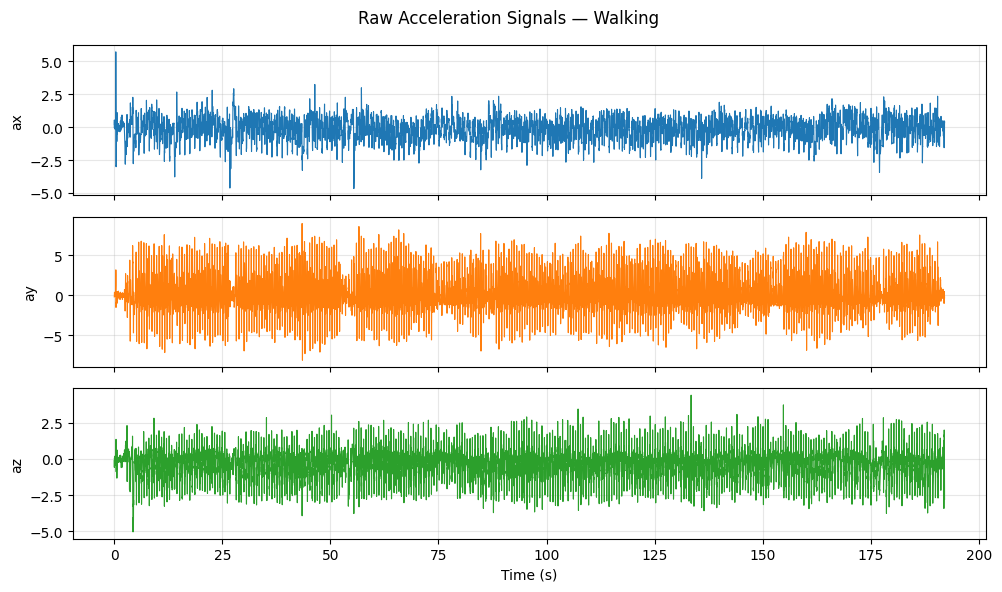

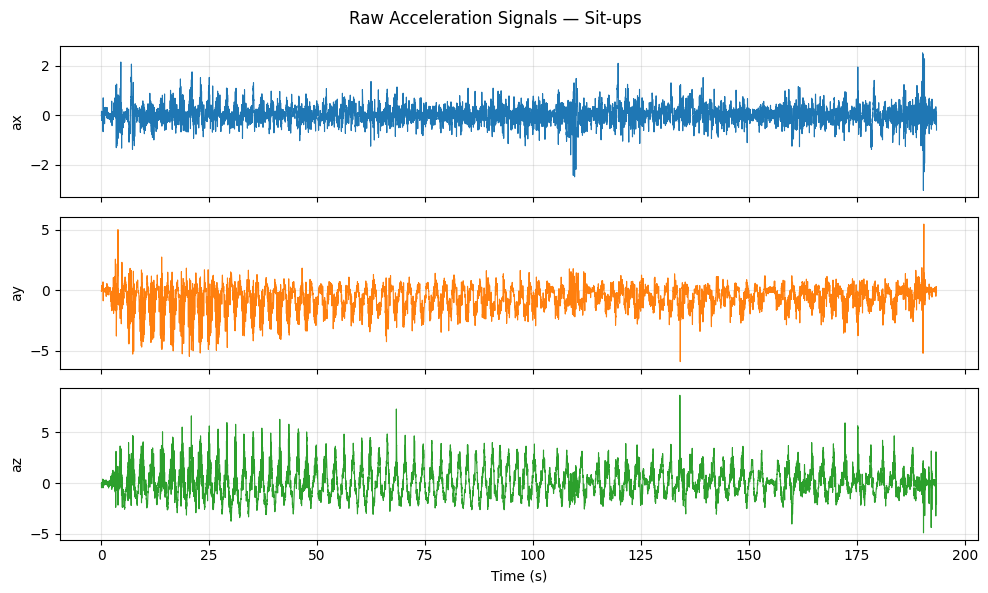

In [6]:
def plot_raw_signal(df, activity_name):
    """Plot the raw X, Y, Z acceleration signals for one activity, if data is available."""
    if df is None or df.empty:
        print(f"[{activity_name}] No data available to plot yet.")
        return

    x_axis = df["time"].values if "time" in df.columns else np.arange(len(df))
    x_label = "Time (s)" if "time" in df.columns else "Sample index"

    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    for ax_obj, col, color in zip(axes, ["ax", "ay", "az"], ["tab:blue", "tab:orange", "tab:green"]):
        if col in df.columns:
            ax_obj.plot(x_axis, df[col].values, color=color, linewidth=0.8)
        ax_obj.set_ylabel(col)
        ax_obj.grid(True, alpha=0.3)
    axes[-1].set_xlabel(x_label)
    fig.suptitle(f"Raw Acceleration Signals — {activity_name}")
    plt.tight_layout()
    plt.show()


for activity_name in CLASS_NAMES:
    plot_raw_signal(CLEAN_DATA[activity_name]["df"], activity_name)

## 5. Resampling to 100 Hz & 1-Second Windowing

The cleaned recordings (Section 4) have an estimated **native sampling rate of ~125 Hz**, not
the 100 Hz required by the experiment — taking 100 raw samples at ~125 Hz would only span
**~0.8 s**, not 1 s. To make **100 samples genuinely equal 1 second**, each recording is first
resampled onto a uniform **100 Hz** grid using linear interpolation on the real timestamps
(every output value lies between two real, adjacent recorded samples — no samples are
fabricated or discarded by this step).

Each resampled recording (one file per activity: `idle.csv`, `walking.csv`, `situps.csv`) is
then segmented **independently** into **1-second, non-overlapping windows**:

```
WINDOW_SIZE = 100 samples (at 100 Hz = 1 second)
```

Each window retains the `ax`, `ay`, `az` values of 100 consecutive samples and remains
associated with its activity class. This is a **contiguous segmentation** of the time-series
(not a random individual-sample split), so that each window preserves the temporal structure
of the underlying signal.

Only **complete** 100-sample windows are used; the exact number of samples and windows is
always calculated from the actual (resampled) recording rather than assumed. Any trailing
samples that do not fill a full window are **discarded** — never padded or fabricated. The code
below reports, directly from the actual data, the resampling summary and a summary of input
samples, complete windows generated, and discarded samples for each activity.


In [7]:
def resample_to_target_rate(df, target_rate_hz=TARGET_SAMPLING_RATE_HZ):
    """
    Resample one cleaned activity recording from its estimated native rate
    (~125 Hz for these phyphox recordings) onto a uniform target_rate_hz (100 Hz)
    grid, using linear interpolation on the real timestamps.

    Every output sample is a linear interpolation between two real, adjacent
    recorded samples -- no samples are fabricated or discarded. After this step,
    `target_rate_hz` consecutive samples correspond to exactly 1 second.
    """
    if df is None or df.empty or "time" not in df.columns:
        return df

    t_raw = df["time"].values
    duration = t_raw[-1] - t_raw[0]
    n_out = int(np.floor(duration * target_rate_hz)) + 1
    t_new = t_raw[0] + np.arange(n_out) / target_rate_hz

    resampled = {"time": t_new}
    for c in ["ax", "ay", "az"]:
        resampled[c] = np.interp(t_new, t_raw, df[c].values)

    return pd.DataFrame(resampled)


RESAMPLING_SUMMARY_ROWS = []
for activity_name in CLASS_NAMES:
    original_df = CLEAN_DATA[activity_name]["df"]
    original_fs = CLEAN_DATA[activity_name]["fs"]
    resampled_df = resample_to_target_rate(original_df, TARGET_SAMPLING_RATE_HZ)

    RESAMPLING_SUMMARY_ROWS.append({
        "Activity": activity_name,
        "Original Samples": len(original_df) if original_df is not None else 0,
        "Estimated Original Rate (Hz)": round(original_fs, 2) if original_fs else None,
        "Resampled Samples": len(resampled_df) if resampled_df is not None else 0,
        "Target Rate (Hz)": TARGET_SAMPLING_RATE_HZ,
    })

    CLEAN_DATA[activity_name]["df"] = resampled_df
    CLEAN_DATA[activity_name]["fs"] = float(TARGET_SAMPLING_RATE_HZ)

resampling_summary_df = pd.DataFrame(RESAMPLING_SUMMARY_ROWS)
print("Resampling summary (native rate -> 100 Hz, via linear interpolation on real timestamps):")
display(resampling_summary_df)


Resampling summary (native rate -> 100 Hz, via linear interpolation on real timestamps):


,Activity,Original Samples,Estimated Original Rate (Hz),Resampled Samples,Target Rate (Hz)
0,Idle,22795,124.96,18243,100
1,Walking,23998,124.97,19204,100
2,Sit-ups,24178,125.00,19343,100


In [8]:
def create_windows(data, window_size=WINDOW_SIZE):
    """
    Split ONE continuous activity recording into consecutive, non-overlapping
    fixed-size windows.

    Each of the three activity recordings (idle.csv, walking.csv, situps.csv) is a
    single continuous ~3-minute capture containing only its own activity, and is
    windowed independently here — no merging with other files, no shuffling, and
    no splitting into smaller sub-files beforehand.

    Only COMPLETE windows of exactly `window_size` samples are kept. If the recording
    ends with fewer than `window_size` samples remaining, that trailing partial window
    is discarded — it is never padded or filled with fabricated values.

    Parameters
    ----------
    data : pandas.DataFrame
        Cleaned activity dataframe containing 'ax', 'ay', 'az' columns.
    window_size : int
        Number of consecutive samples per window (100 for a 1-second window at 100 Hz).

    Returns
    -------
    list of pandas.DataFrame
        Each element is one complete window (window_size rows x ['ax','ay','az']).
    int
        Number of trailing samples at the end of the recording that did not fill a
        complete window and were therefore discarded (not padded with fabricated values).
    """
    if data is None or data.empty:
        return [], 0

    signal = data[["ax", "ay", "az"]].reset_index(drop=True)
    n_samples = len(signal)
    n_windows = n_samples // window_size          # complete windows only
    n_leftover = n_samples - (n_windows * window_size)  # discarded, never padded

    windows = []
    for i in range(n_windows):
        start = i * window_size
        end = start + window_size
        windows.append(signal.iloc[start:end].reset_index(drop=True))

    return windows, n_leftover


WINDOWS_BY_CLASS = {}
WINDOWING_SUMMARY_ROWS = []

for activity_name in CLASS_NAMES:
    df = CLEAN_DATA[activity_name]["df"]
    windows, n_leftover = create_windows(df, window_size=WINDOW_SIZE)
    WINDOWS_BY_CLASS[activity_name] = windows

    input_samples = len(df) if df is not None else 0
    WINDOWING_SUMMARY_ROWS.append({
        "Activity": activity_name,
        "Input Samples (100 Hz)": input_samples,
        "Complete 1-sec Windows": len(windows),
        "Discarded Samples": n_leftover,
    })

# Automatically calculated summary of the actual windowing result for each recording
# (no assumed/fixed sample or window counts — everything below comes from the real CSVs).
windowing_summary_df = pd.DataFrame(
    WINDOWING_SUMMARY_ROWS,
    columns=["Activity", "Input Samples (100 Hz)", "Complete 1-sec Windows", "Discarded Samples"],
)

print("Windowing summary (calculated automatically from the resampled 100 Hz recordings):")
display(windowing_summary_df)

print()
# Show an example window, if available
for activity_name in CLASS_NAMES:
    if len(WINDOWS_BY_CLASS[activity_name]) > 0:
        print(f"Example window from '{activity_name}':")
        display(WINDOWS_BY_CLASS[activity_name][0])
        break
else:
    print("No windows available yet — place the real CSV files in the dataset folder and rerun.")


Windowing summary (calculated automatically from the resampled 100 Hz recordings):


,Activity,Input Samples (100 Hz),Complete 1-sec Windows,Discarded Samples
0,Idle,18243,182,43
1,Walking,19204,192,4
2,Sit-ups,19343,193,43



Example window from 'Idle':


,ax,ay,az
0,-0.012026,0.287814,0.210193
1,-0.034622,0.206523,-0.402032
2,-0.044108,0.326069,-0.555328
3,-0.084968,0.453935,-0.471474
4,-0.075181,0.448608,-0.387462
...,...,...,...
95,0.094096,0.177297,0.014284
96,0.052169,0.122509,0.046531
97,0.035824,0.077056,0.058845
98,0.008660,0.064922,0.024265


## 6. 3D Acceleration Magnitude

For every sample inside every window, the **3D Acceleration Magnitude** is computed using
all three axes (X, Y and Z are all retained — the Z-axis is **not** discarded):

```
a_mag = sqrt(ax^2 + ay^2 + az^2)
```

A representative window from each of the three activities (Idle, Walking, Sit-ups) is plotted
below to visually compare the 3D Acceleration Magnitude across classes.

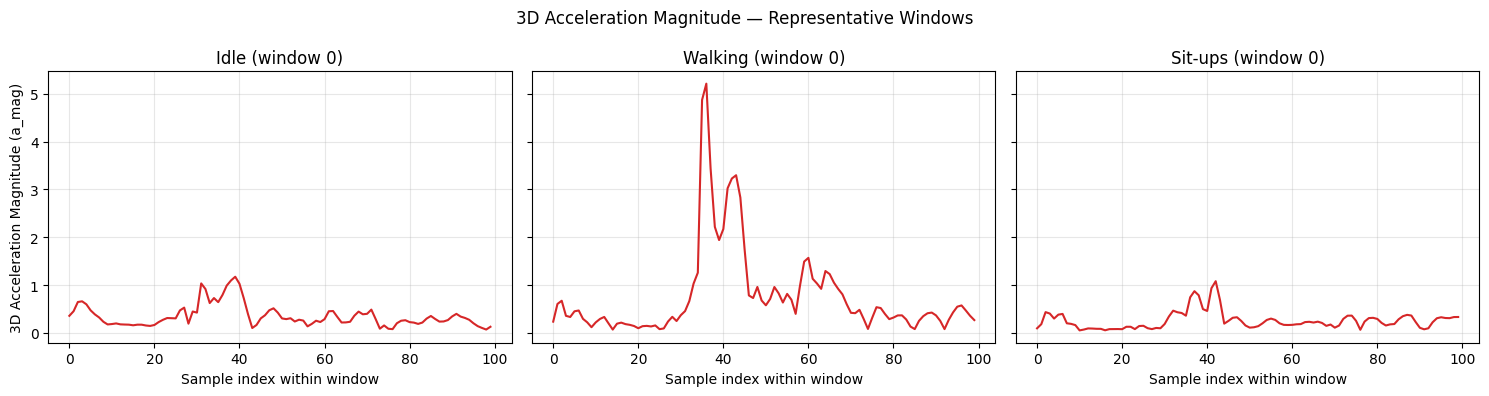

In [9]:
def compute_magnitude(window_df):
    """
    Compute the 3D Acceleration Magnitude (a_mag) for every sample in a window.
    a_mag = sqrt(ax^2 + ay^2 + az^2)
    """
    ax = window_df["ax"].values
    ay = window_df["ay"].values
    az = window_df["az"].values
    a_mag = np.sqrt(ax**2 + ay**2 + az**2)
    return a_mag


MAGNITUDES_BY_CLASS = {}
for activity_name in CLASS_NAMES:
    mags = [compute_magnitude(w) for w in WINDOWS_BY_CLASS[activity_name]]
    MAGNITUDES_BY_CLASS[activity_name] = mags

# Plot the 3D Acceleration Magnitude of one representative window per class
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax_obj, activity_name in zip(axes, CLASS_NAMES):
    mags = MAGNITUDES_BY_CLASS[activity_name]
    if len(mags) > 0:
        ax_obj.plot(mags[0], color="tab:red")
        ax_obj.set_title(f"{activity_name} (window 0)")
    else:
        ax_obj.set_title(f"{activity_name} (no data yet)")
    ax_obj.set_xlabel("Sample index within window")
    ax_obj.grid(True, alpha=0.3)
axes[0].set_ylabel("3D Acceleration Magnitude (a_mag)")
fig.suptitle("3D Acceleration Magnitude — Representative Windows")
plt.tight_layout()
plt.show()

## 7. Feature Extraction per Window

For every 1-second window, exactly **three** statistical features are computed from its
3D Acceleration Magnitude signal (`a_mag`):

1. **Mean**

   `mu = (1/N) * sum(a_mag_i)`

2. **Standard Deviation**

   `sigma = sqrt((1/N) * sum((a_mag_i - mu)^2))`

3. **RMS (Root Mean Square)**

   `RMS = sqrt((1/N) * sum(a_mag_i^2))`

No additional machine-learning features are introduced beyond these three, as required by
the experiment. A sample feature table is displayed below.

In [10]:
def extract_features(a_mag):
    """
    Compute Mean, Standard Deviation and RMS of a 3D Acceleration Magnitude window.
    Returns a dict: {'mean': ..., 'std': ..., 'rms': ...}
    """
    n = len(a_mag)
    mu = float(np.sum(a_mag) / n)
    sigma = float(np.sqrt(np.sum((a_mag - mu) ** 2) / n))
    rms = float(np.sqrt(np.sum(a_mag ** 2) / n))
    return {"mean": mu, "std": sigma, "rms": rms}


FEATURES_BY_CLASS = {}
for activity_name in CLASS_NAMES:
    feats = [extract_features(m) for m in MAGNITUDES_BY_CLASS[activity_name]]
    FEATURES_BY_CLASS[activity_name] = feats

# Build a small sample feature table for inspection
sample_rows = []
for activity_name in CLASS_NAMES:
    for feat in FEATURES_BY_CLASS[activity_name][:5]:
        row = {"activity": activity_name}
        row.update(feat)
        sample_rows.append(row)

sample_feature_table = pd.DataFrame(sample_rows)
print("Sample feature table (first few windows per class):")
display(sample_feature_table)

Sample feature table (first few windows per class):


,activity,mean,std,rms
0,Idle,0.351536,0.231825,0.421094
1,Idle,0.151143,0.062437,0.163532
2,Idle,0.151240,0.157540,0.218386
3,Idle,0.117052,0.051292,0.127797
4,Idle,0.125359,0.055371,0.137043
5,Walking,0.772973,0.946000,1.221639
6,Walking,0.381062,0.239025,0.449824
7,Walking,1.276660,0.995078,1.618654
8,Walking,1.657142,1.342320,2.132591
9,Walking,2.760663,1.848349,3.322296


## 8. Feature Matrix (X) & Labels (y)

The extracted (mean, std, rms) features from every window are assembled into the input
feature matrix:

```
X = [ mean, std, rms ]
```

and the corresponding activity label is assigned to each window using:

```
0 = Idle
1 = Walking
2 = Sit-ups
```

The resulting shapes and class distribution are displayed below, along with a simple
class-distribution visualization.

Feature matrix X shape: (567, 3)
Label vector y shape: (567,)

First few feature rows:


,mean,std,rms,activity
0,0.351535,0.231825,0.421094,Idle
1,0.151143,0.062437,0.163532,Idle
2,0.151240,0.157540,0.218386,Idle
3,0.117052,0.051292,0.127797,Idle
4,0.125359,0.055371,0.137043,Idle



Class distribution:


,count
activity,
Idle,182
Walking,192
Sit-ups,193


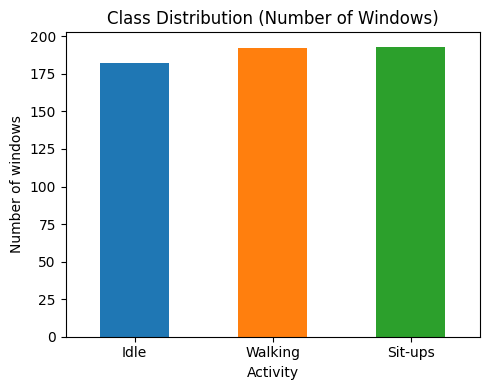

In [11]:
X_rows = []
y_rows = []

for activity_name in CLASS_NAMES:
    label = LABEL_MAP[activity_name]
    for feat in FEATURES_BY_CLASS[activity_name]:
        X_rows.append([feat["mean"], feat["std"], feat["rms"]])
        y_rows.append(label)

X = np.array(X_rows, dtype=np.float32)
y = np.array(y_rows, dtype=np.int64)

print("Feature matrix X shape:", X.shape)
print("Label vector y shape:", y.shape)

feature_df = pd.DataFrame(X, columns=["mean", "std", "rms"])
feature_df["activity"] = [CLASS_NAMES[i] for i in y]
print("\nFirst few feature rows:")
display(feature_df.head())

print("\nClass distribution:")
class_counts = feature_df["activity"].value_counts().reindex(CLASS_NAMES)
display(class_counts)

# Simple class-distribution visualization
plt.figure(figsize=(5, 4))
class_counts.plot(kind="bar", color=["tab:blue", "tab:orange", "tab:green"])
plt.title("Class Distribution (Number of Windows)")
plt.xlabel("Activity")
plt.ylabel("Number of windows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Train/Test Split

A **stratified** train/test split is used so that all three activity classes are
proportionally represented in both the training and test sets. An 80% / 20% split is used,
with a fixed random state (`random_state = 42`) for reproducibility.

This split is performed **after** feature extraction (i.e. at the window/feature level, not
at the raw-sample level), as required by the experiment.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

def class_distribution(y_arr, title):
    counts = pd.Series(y_arr).value_counts().sort_index()
    counts.index = [CLASS_NAMES[i] for i in counts.index]
    print(f"\n{title}:")
    display(counts)

class_distribution(y_train, "Training set class distribution")
class_distribution(y_test, "Test set class distribution")

X_train shape: (453, 3)
X_test shape : (114, 3)
y_train shape: (453,)
y_test shape : (114,)

Training set class distribution:


,count
Idle,146
Walking,153
Sit-ups,154



Test set class distribution:


,count
Idle,36
Walking,39
Sit-ups,39


## 10. Baseline 3-Class MLP

A lightweight Multi-Layer Perceptron (MLP) is trained on the three extracted features
(mean, std, rms). The network is intentionally kept small, since the experiment targets
eventual TinyML / microcontroller deployment.

**Architecture:**

```
Input(3) -> Dense(16, relu) -> Dense(8, relu) -> Dense(3, softmax)
```

The model is compiled with `sparse_categorical_crossentropy` loss and the Adam optimizer.
Training uses only the training data (`X_train`, `y_train`), with a validation split carved
out of the training set; the test set is **not** used during training.

In [13]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(3,), name="features_mean_std_rms"),
        layers.Dense(16, activation="relu", name="dense_1"),
        layers.Dense(8, activation="relu", name="dense_2"),
        layers.Dense(len(CLASS_NAMES), activation="softmax", name="output"),
    ], name="HAR_Baseline_MLP")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


baseline_model = build_baseline_model()
baseline_model.summary()

print("\nTotal trainable parameters:", baseline_model.count_params())

Model: "HAR_Baseline_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227 (908.00 B)

 Trainable params: 227 (908.00 B)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 227


In [14]:
EPOCHS = 60
BATCH_SIZE = 16

history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3591 - loss: 1.0478 - val_accuracy: 0.5934 - val_loss: 0.9791
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5000 - loss: 0.9575 - val_accuracy: 0.6703 - val_loss: 0.9062
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6575 - loss: 0.9008 - val_accuracy: 0.6703 - val_loss: 0.8568
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6713 - loss: 0.8609 - val_accuracy: 0.6813 - val_loss: 0.8207
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6713 - loss: 0.8286 - val_accuracy: 0.7033 - val_loss: 0.7893
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6906 - loss: 0.8001 - val_accuracy: 0.7363 - val_loss: 0.7622
Epoch 7/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7127 - loss: 0.7735 - val_accuracy: 0.7582 - val_loss: 0.7353
Epoch 8/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7541 - loss: 0.7460 - val_accuracy: 0.8352 - v

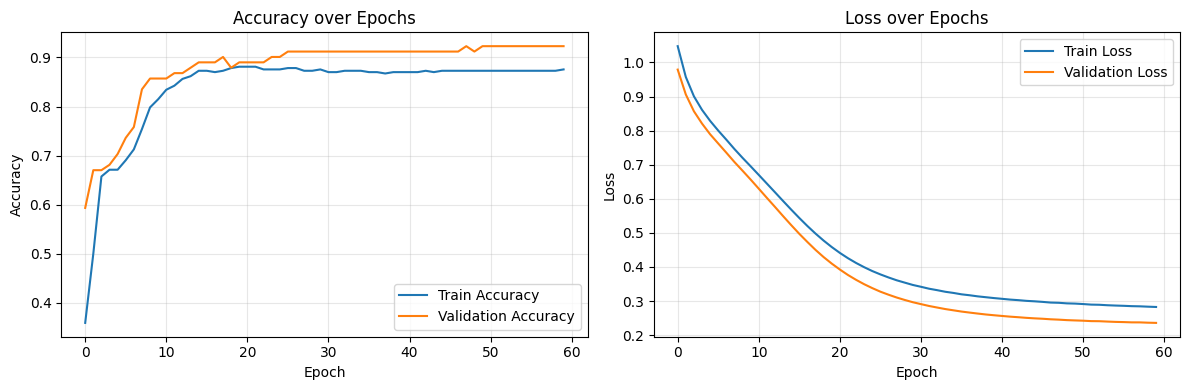

In [15]:
# Plot training/validation accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Baseline Model Evaluation

The trained **Float32 baseline** model is evaluated on the held-out test set
(`X_test`, `y_test`), which was not used during training. Test accuracy, precision, recall,
F1-score and the confusion matrix are computed. The baseline predictions are stored, since
they will be useful for comparison with the TFLite model variants later in the notebook.

Baseline (Float32, Keras) Test Accuracy: 85.09%
Baseline (Float32, Keras) Test Loss    : 0.3190
Precision (weighted): 0.8515
Recall    (weighted): 0.8509
F1-score  (weighted): 0.8493

Classification Report (Float32 Baseline):
              precision    recall  f1-score   support

        Idle       0.97      1.00      0.99        36
     Walking       0.82      0.72      0.77        39
     Sit-ups       0.77      0.85      0.80        39

    accuracy                           0.85       114
   macro avg       0.85      0.85      0.85       114
weighted avg       0.85      0.85      0.85       114



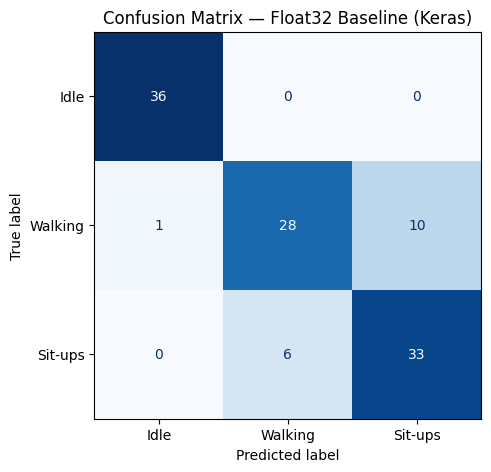

In [16]:
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline (Float32, Keras) Test Accuracy: {baseline_test_accuracy * 100:.2f}%")
print(f"Baseline (Float32, Keras) Test Loss    : {baseline_test_loss:.4f}")

# Store baseline predictions for later comparison with TFLite models
baseline_pred_probs = baseline_model.predict(X_test, verbose=0)
baseline_test_predictions = np.argmax(baseline_pred_probs, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, baseline_test_predictions, average="weighted", zero_division=0
)
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall    (weighted): {recall:.4f}")
print(f"F1-score  (weighted): {f1:.4f}")

print("\nClassification Report (Float32 Baseline):")
print(classification_report(
    y_test, baseline_test_predictions, target_names=CLASS_NAMES, zero_division=0
))

cm = confusion_matrix(y_test, baseline_test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Float32 Baseline (Keras)")
plt.tight_layout()
plt.show()

## 12. TensorFlow Lite Conversion

The trained Keras MLP is now converted into TensorFlow Lite (TFLite) format. Four required
variants will be produced (implemented in detail in Section 13):

- **A.** Float32 Baseline (Unquantized)
- **B.** Dynamic Range Quantization
- **C.** Float16 Quantization
- **D.** Full Integer Post-Training Quantization (PTQ)

An output directory is created to hold the converted `.tflite` model files, each saved with
a clear, descriptive filename.

In [17]:
TFLITE_DIR = "tflite_models"
os.makedirs(TFLITE_DIR, exist_ok=True)

MODEL_FLOAT32_PATH = os.path.join(TFLITE_DIR, "model_float32.tflite")
MODEL_DYNAMIC_RANGE_PATH = os.path.join(TFLITE_DIR, "model_dynamic_range.tflite")
MODEL_FLOAT16_PATH = os.path.join(TFLITE_DIR, "model_float16.tflite")
MODEL_INT8_PATH = os.path.join(TFLITE_DIR, "model_int8.tflite")

print("TFLite output directory:", TFLITE_DIR)
print("Planned output files:")
for p in [MODEL_FLOAT32_PATH, MODEL_DYNAMIC_RANGE_PATH, MODEL_FLOAT16_PATH, MODEL_INT8_PATH]:
    print(" -", p)

TFLite output directory: tflite_models
Planned output files:
 - tflite_models/model_float32.tflite
 - tflite_models/model_dynamic_range.tflite
 - tflite_models/model_float16.tflite
 - tflite_models/model_int8.tflite


## 13. Four TFLite Quantization Variants

This section implements all four required TFLite conversion variants using the trained
Keras baseline model.

### 13A. Float32 Baseline (Unquantized)

The original Keras model is converted directly to TFLite with no optimization applied. Both
weights and activations remain in Float32. This serves as the reference baseline for the
model size and accuracy comparisons in Section 15.

In [18]:
converter_f32 = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
tflite_float32_model = converter_f32.convert()

with open(MODEL_FLOAT32_PATH, "wb") as f:
    f.write(tflite_float32_model)

print(f"Saved Float32 unquantized TFLite model to: {MODEL_FLOAT32_PATH}")
print(f"File size: {os.path.getsize(MODEL_FLOAT32_PATH) / 1024:.2f} KB")

Saved artifact at '/tmp/tmpi03qjf30'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='features_mean_std_rms')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138841287465424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287465232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287469648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287471568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287471376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287462544: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved Float32 unquantized TFLite model to: tflite_models/model_float32.tflite
File size: 3.02 KB


### 13B. Dynamic Range Quantization

Dynamic Range Quantization quantizes the model **weights** to 8-bit integers ahead of time,
while **activations** remain in floating point and are computed dynamically at inference
time. This is enabled by simply setting the default optimization flag on the converter.

In [19]:
converter_dr = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter_dr.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_dynamic_range_model = converter_dr.convert()

with open(MODEL_DYNAMIC_RANGE_PATH, "wb") as f:
    f.write(tflite_dynamic_range_model)

print(f"Saved Dynamic Range quantized TFLite model to: {MODEL_DYNAMIC_RANGE_PATH}")
print(f"File size: {os.path.getsize(MODEL_DYNAMIC_RANGE_PATH) / 1024:.2f} KB")

Saved artifact at '/tmp/tmpt_d5c18z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='features_mean_std_rms')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138841287465424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287465232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287469648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287471568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287471376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287462544: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved Dynamic Range quantized TFLite model to: tflite_models/model_dynamic_range.tflite
File size: 3.02 KB


### 13C. Float16 Quantization

Float16 quantization stores the model **weights** in 16-bit floating point instead of
32-bit, roughly halving the weight storage size. Depending on the target hardware/runtime,
inference may still be carried out using floating-point computation (with weights
dequantized to float32 on the fly, or computed natively in float16 on supporting hardware).

In [20]:
converter_f16 = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter_f16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_f16.target_spec.supported_types = [tf.float16]
tflite_float16_model = converter_f16.convert()

with open(MODEL_FLOAT16_PATH, "wb") as f:
    f.write(tflite_float16_model)

print(f"Saved Float16 quantized TFLite model to: {MODEL_FLOAT16_PATH}")
print(f"File size: {os.path.getsize(MODEL_FLOAT16_PATH) / 1024:.2f} KB")

Saved artifact at '/tmp/tmp5c_c0744'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='features_mean_std_rms')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138841287465424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287465232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287469648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287471568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287471376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287462544: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved Float16 quantized TFLite model to: tflite_models/model_float16.tflite
File size: 3.34 KB


### 13D. Full Integer Post-Training Quantization (PTQ)

Full Integer PTQ quantizes **both weights and activations** to 8-bit integers, which is the
most aggressive of the four schemes and is best suited to microcontroller-class hardware
that lacks a floating-point unit.

This requires a **representative calibration dataset**: a small sample of real, in-range
input examples (drawn here from `X_train`) that the converter uses to observe the typical
range of activation values at each layer, so that appropriate int8 quantization scales and
zero-points can be computed. Without this calibration step, the converter would have no way
of knowing the expected numeric range of the model's inputs and intermediate activations,
and could not produce a valid integer-only quantization.

In [21]:
def representative_dataset():
    """
    Yield representative, real (non-fabricated) input samples drawn from the actual
    training feature matrix X_train, used by the TFLite converter to calibrate the
    int8 quantization ranges for Full Integer PTQ.
    """
    for i in range(X_train.shape[0]):
        sample = X_train[i:i + 1].astype(np.float32)  # shape (1, 3), matches model input
        yield [sample]


converter_int8 = tf.lite.TFLiteConverter.from_keras_model(baseline_model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8_model = converter_int8.convert()

with open(MODEL_INT8_PATH, "wb") as f:
    f.write(tflite_int8_model)

print(f"Saved Full Integer PTQ TFLite model to: {MODEL_INT8_PATH}")
print(f"File size: {os.path.getsize(MODEL_INT8_PATH) / 1024:.2f} KB")

Saved artifact at '/tmp/tmppg5ffh59'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='features_mean_std_rms')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138841287465424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287465232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287469648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287471568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287471376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138841287462544: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved Full Integer PTQ TFLite model to: tflite_models/model_int8.tflite
File size: 3.33 KB


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## 14. TFLite Inference

All four TFLite models must be evaluated on the **same** test dataset (`X_test`, `y_test`)
so that the comparison in Section 15 is fair.

A single, generic inference function is implemented below. Because the four models do
**not** all share the same input datatype (the Float32, Dynamic Range and Float16 models
expect `float32` input, while the Full Integer PTQ model expects `int8` input), the function
inspects `input_details[0]["dtype"]` and `input_details[0]["quantization"]` for each model
and handles the required quantization/dequantization accordingly.

In [22]:
def run_tflite_inference(tflite_path, X_input):
    """
    Run inference for every row of X_input through a given TFLite model, handling
    both floating-point and int8-quantized models automatically.

    Returns
    -------
    predictions : np.ndarray of shape (n_samples,)
        Predicted class indices.
    interpreter : tf.lite.Interpreter
        The (already allocated) interpreter, reusable for timing benchmarks.
    """
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_dtype = input_details[0]["dtype"]
    input_scale, input_zero_point = input_details[0]["quantization"]

    output_dtype = output_details[0]["dtype"]
    output_scale, output_zero_point = output_details[0]["quantization"]

    predictions = []

    for i in range(X_input.shape[0]):
        sample = X_input[i:i + 1].astype(np.float32)

        if input_dtype == np.int8 or input_dtype == np.uint8:
            # Quantize the floating-point input into the model's integer domain
            if input_scale == 0:
                quantized_sample = sample.astype(input_dtype)
            else:
                quantized_sample = (sample / input_scale) + input_zero_point
                quantized_sample = np.clip(
                    quantized_sample,
                    np.iinfo(input_dtype).min,
                    np.iinfo(input_dtype).max,
                ).astype(input_dtype)
            interpreter.set_tensor(input_details[0]["index"], quantized_sample)
        else:
            interpreter.set_tensor(input_details[0]["index"], sample.astype(input_dtype))

        interpreter.invoke()
        raw_output = interpreter.get_tensor(output_details[0]["index"])[0]

        if output_dtype == np.int8 or output_dtype == np.uint8:
            if output_scale == 0:
                dequantized_output = raw_output.astype(np.float32)
            else:
                dequantized_output = (raw_output.astype(np.float32) - output_zero_point) * output_scale
        else:
            dequantized_output = raw_output.astype(np.float32)

        predicted_class = int(np.argmax(dequantized_output))
        predictions.append(predicted_class)

    return np.array(predictions), interpreter


TFLITE_MODEL_PATHS = {
    "Float32 Baseline": MODEL_FLOAT32_PATH,
    "Dynamic Range": MODEL_DYNAMIC_RANGE_PATH,
    "Float16": MODEL_FLOAT16_PATH,
    "Full Integer PTQ": MODEL_INT8_PATH,
}

tflite_predictions = {}
tflite_accuracies = {}

for model_name, model_path in TFLITE_MODEL_PATHS.items():
    preds, _ = run_tflite_inference(model_path, X_test)
    acc = accuracy_score(y_test, preds)
    tflite_predictions[model_name] = preds
    tflite_accuracies[model_name] = acc
    print(f"{model_name:<20s} -> Test Accuracy: {acc * 100:.2f}%")

Float32 Baseline     -> Test Accuracy: 85.09%
Dynamic Range        -> Test Accuracy: 85.09%
Float16              -> Test Accuracy: 85.09%
Full Integer PTQ     -> Test Accuracy: 86.84%


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

## 15. Deployment Metrics

Four metrics are computed automatically for each TFLite model (no values are hard-coded):

1. **Model size (KB)** — actual `.tflite` file size on disk.
2. **Accuracy (%)** — on the same held-out test set for all models.
3. **Memory reduction (%)** — file-size reduction relative to the Float32 baseline (a proxy for ROM footprint, not runtime RAM).
4. **Avg. inference time (µs/window)** — via `time.perf_counter()`, after a warm-up run, averaged over repeated passes identical across all models (model loading excluded).


In [23]:
def get_model_size_kb(model_path):
    return os.path.getsize(model_path) / 1024.0


def benchmark_inference_time(model_path, X_input, n_repeats=50, n_warmup=5):
    """
    Benchmark average per-window inference time for a TFLite model.

    - Excludes model loading time (interpreter is created once, outside timing).
    - Performs `n_warmup` untimed warm-up inferences before timing.
    - Repeats the full pass over X_input `n_repeats` times and averages,
      to obtain a stable estimate.

    Returns
    -------
    avg_time_us_per_window : float
    """
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_dtype = input_details[0]["dtype"]
    input_scale, input_zero_point = input_details[0]["quantization"]

    def prepare_input(sample):
        sample = sample.astype(np.float32)
        if input_dtype == np.int8 or input_dtype == np.uint8:
            if input_scale == 0:
                return sample.astype(input_dtype)
            q = (sample / input_scale) + input_zero_point
            q = np.clip(q, np.iinfo(input_dtype).min, np.iinfo(input_dtype).max)
            return q.astype(input_dtype)
        return sample.astype(input_dtype)

    # Warm-up (untimed)
    for i in range(min(n_warmup, X_input.shape[0])):
        sample = prepare_input(X_input[i:i + 1])
        interpreter.set_tensor(input_details[0]["index"], sample)
        interpreter.invoke()
        _ = interpreter.get_tensor(output_details[0]["index"])

    # Timed runs
    total_time_sec = 0.0
    total_windows = 0

    for _ in range(n_repeats):
        for i in range(X_input.shape[0]):
            sample = prepare_input(X_input[i:i + 1])
            interpreter.set_tensor(input_details[0]["index"], sample)

            start = time.perf_counter()
            interpreter.invoke()
            end = time.perf_counter()

            _ = interpreter.get_tensor(output_details[0]["index"])

            total_time_sec += (end - start)
            total_windows += 1

    avg_time_sec_per_window = total_time_sec / total_windows
    avg_time_us_per_window = avg_time_sec_per_window * 1e6
    return avg_time_us_per_window


N_TIMING_REPEATS = 50  # same number of repetitions used for every model, for a fair comparison

deployment_metrics = []

float32_size_kb = get_model_size_kb(MODEL_FLOAT32_PATH)

for model_name, model_path in TFLITE_MODEL_PATHS.items():
    size_kb = get_model_size_kb(model_path)
    accuracy_pct = tflite_accuracies[model_name] * 100.0
    memory_reduction_pct = ((float32_size_kb - size_kb) / float32_size_kb) * 100.0
    avg_inference_time_us = benchmark_inference_time(model_path, X_test, n_repeats=N_TIMING_REPEATS)

    deployment_metrics.append({
        "Model": model_name,
        "Model Size (KB)": round(size_kb, 3),
        "Accuracy (%)": round(accuracy_pct, 2),
        "Memory Reduction (%)": round(memory_reduction_pct, 2),
        "Average Inference Time (µs/window)": round(avg_inference_time_us, 2),
    })

deployment_metrics_df = pd.DataFrame(deployment_metrics)
print("Deployment metrics (computed automatically from the actual saved models):")
display(deployment_metrics_df)

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Deployment metrics (computed automatically from the actual saved models):


,Model,Model Size (KB),Accuracy (%),Memory Reduction (%),Average Inference Time (µs/window)
0,Float32 Baseline,3.023,85.09,0.00,2.33
1,Dynamic Range,3.023,85.09,0.00,1.47
2,Float16,3.340,85.09,-10.47,1.49
3,Full Integer PTQ,3.328,86.84,-10.08,2.83


## 16. Comparative Analysis

The table and charts below compare the four TFLite variants across all four deployment metrics, using values taken directly from `deployment_metrics_df` (Section 15) — none are manually entered.


In [24]:
# Ensure rows are in the required, fixed order for reporting
row_order = ["Float32 Baseline", "Dynamic Range", "Float16", "Full Integer PTQ"]
results_df = deployment_metrics_df.set_index("Model").loc[row_order].reset_index()

print("Final Comparative Results Table:")
display(results_df)

Final Comparative Results Table:


,Model,Model Size (KB),Accuracy (%),Memory Reduction (%),Average Inference Time (µs/window)
0,Float32 Baseline,3.023,85.09,0.00,2.33
1,Dynamic Range,3.023,85.09,0.00,1.47
2,Float16,3.340,85.09,-10.47,1.49
3,Full Integer PTQ,3.328,86.84,-10.08,2.83


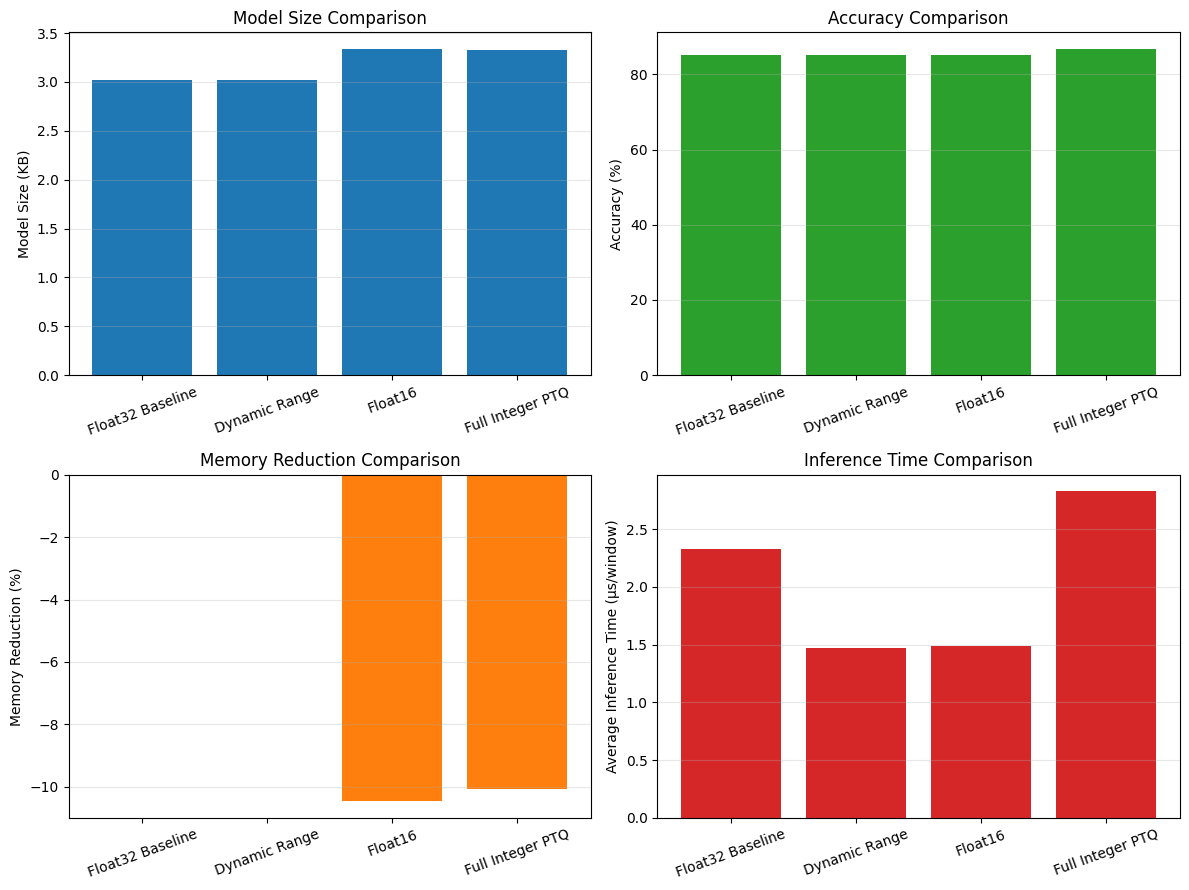

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

metrics_to_plot = [
    ("Model Size (KB)", "tab:blue", "Model Size Comparison"),
    ("Accuracy (%)", "tab:green", "Accuracy Comparison"),
    ("Memory Reduction (%)", "tab:orange", "Memory Reduction Comparison"),
    ("Average Inference Time (µs/window)", "tab:red", "Inference Time Comparison"),
]

for ax_obj, (col, color, title) in zip(axes.flat, metrics_to_plot):
    ax_obj.bar(results_df["Model"], results_df[col], color=color)
    ax_obj.set_title(title)
    ax_obj.set_ylabel(col)
    ax_obj.tick_params(axis="x", rotation=20)
    ax_obj.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Quantization Analysis

Section 13 described how each scheme works; the actual measured trade-offs are in `results_df`
(Section 16) — read this alongside those numbers, not as a general ranking.

For a model this small (a few thousand parameters, only a few KB), the **`.tflite` file's fixed
metadata/runtime overhead (buffers, quantization parameters, flatbuffer scaffolding) can be
comparable to or larger than the space saved by quantizing the weights**. As a result, Dynamic
Range may show little or no size reduction, and Float16 / Full Integer PTQ can even end up
**larger** than the Float32 baseline for this particular model — the reduction typically only
becomes apparent for bigger networks where parameter storage dominates the file size.
`results_df` reports whatever reduction is actually measured (positive, zero, or negative); no
value is adjusted to make a scheme look better.

**Full Integer PTQ remains relevant for microcontroller deployment even without a size win
here**, since it is the only variant that replaces floating-point weights *and* activations with
int8, removing the need for a hardware FPU and enabling integer-only inference on MCU-class
hardware — independent of whether the file itself happens to be smaller for a model this tiny.


## 18. Final Experimental Summary

Real triaxial accelerometer data for Idle, Walking and Sit-ups was cleaned, resampled from its
native ~125 Hz to a true 100 Hz, and segmented into 1-second, 100-sample windows; Mean, Standard
Deviation and RMS were extracted from the 3D acceleration magnitude of each window. A 3-class MLP
trained on these features was converted into four TFLite variants (Float32 Baseline, Dynamic
Range, Float16, Full Integer PTQ) and evaluated on the same test set. Model size, accuracy,
memory reduction and inference time (Sections 15–17) were measured directly from the saved
models: for a model this small, quantization gave little-to-no file-size reduction (fixed TFLite
overhead dominates), but Full Integer PTQ remains the variant best suited to FPU-less
microcontroller deployment.
